In [20]:
import pandas as pd
import numpy as np
import csv
import os
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화
## 2.데이터 전처리
import re                             # 정규식 모듈 임포트
## 3.형태소 처리
from konlpy.tag import Okt
## 4.Word Cloud
import nltk
from collections import Counter
from wordcloud import WordCloud

In [39]:
df = pd.read_csv('BID_Address.csv', encoding='cp949')
df_bu = df
df

,bidID,참가수,공고번호,공고차수,판단번호,항목번호,입찰명,발주기관코드,발주기관,개찰일시,...,대표자,업체주소,낙찰률,낙찰금액,카테고리,pick_keywords,군 분류,주소_대분류,주소_소분류,주소_comb
0,1,81,SFL0160,1,47669,***,임시명찰 등 2품목 구매,SFL,제3283부대,2016-12-30 12:30:00,...,이정구,"경기도 고양시 덕양구 통일로140, 1층 에이143호, 2층 에이261호,지하1층 ...",88.0062,2.368995e+07,2종,명찰,육군,경기도,고양시,경기도 고양시
1,2,1,LFC0043,1,45002,1,장거리 이동 신병 도시락 제조납품,LFC,육군훈련소,2016-12-30 10:00:00,...,이용환,충청북도 옥천군 옥천읍 삼청리877-1,96.8333,5.810000e+03,1종,도시락,육군,충청북도,옥천군,충청북도 옥천군
2,3,22,LGT0034,1,48136,***,0부대 중대시설 분전반 제조설치(16-312),LGT,제2307부대,2016-12-29 11:00:00,...,김화성,강원특별자치도 인제군 북면 원통로74번길10-5(원통농공단지),88.0408,2.909872e+07,4종,제조설치,육군,강원특별자치도,인제군,강원특별자치도 인제군
3,4,22,UMM0839,1,48049,***,13-본-국대-01 00학교 가구 및 비품 제조설치,UMM,국군재정관리단,2016-12-29 11:00:00,...,김준홍,"서울특별시 구로구 구로중앙로134, 4층(구로동, 리치몰)",88.2297,2.165042e+09,2종,가구,기타,서울특별시,구로구,서울특별시 구로구
4,5,9,LGT0035,1,48138,***,00부대 중대시설 조명기구 제조납품(16-314),LGT,제2307부대,2016-12-29 11:00:00,...,이명옥,강원특별자치도 원주시 태장공단길47-0 (태장동),88.3713,3.242441e+07,4종,조명기구,육군,강원특별자치도,원주시,강원특별자치도 원주시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74725,74728,164,SCQ0154,2,54928,***,수영장자동청소기 등 16종 구매,SCQ,제9911부대,2024-01-03 10:30:00,...,김정현,강원특별자치도 강릉시 경강로2496,89.4840,2.548920e+07,2종,청소기,해병,강원특별자치도,강릉시,강원특별자치도 강릉시
74726,74729,33,HCL0005,1,51,***,24년 간부식당 식자재 구매,HCL,공군사관학교,2024-01-03 10:30:00,...,변정순,경기도 파주시 장명산길174-20 (오도동),83.3270,3.519749e+08,1종,부식,공군,경기도,파주시,경기도 파주시
74727,74730,3,SCR0090,2,61362,***,24년 배추김치(포기절단) 등 10종 구매,SCR,해군제3함대사령부,2024-01-03 10:30:00,...,정재웅,전라남도 무안군 망운면 조금나루길22,88.9890,5.389600e+07,1종,김치,해군,전라남도,무안군,전라남도 무안군
74728,74731,31,MDS0030,1,66867,***,교육단 증개축 GHP 실외기 설치납품,MDS,제3707부대,2024-01-03 10:30:00,...,이복경,경기도 의정부시 민락로387-0 (낙양동),88.0390,6.049600e+07,2종,교육,육군,경기도,의정부시,경기도 의정부시


In [8]:
df_add = pd.read_csv('../●송하선_workbook/군_분류_군수품_분류_완료_주소추가.csv', encoding='utf-8-sig')
df_add['Unnamed: 0'].size

74732

In [9]:
df_add.to_csv('forBID_add.csv', index=False, encoding='cp949')

In [14]:
# df_add = pd.read_csv('forBID_add.csv', encoding='cp949')
df_add.head(1)

,bidID,참가수,공고번호,공고차수,판단번호,항목번호,입찰명,업무구분,발주기관코드,발주기관,...,낙찰자(연락처),ss,낙찰자(연락처).1,낙찰자(주소),낙찰률,낙찰금액,군수품분류,군 분류,주소_대분류,주소_소분류
0,1,81,SFL0160,1,47669,***,임시명찰 등 2품목 구매,물품,SFL,제3283부대,...,222730487,222730487,02-2273-0487,"경기도 고양시 덕양구 통일로140, 1층 에이143호, 2층 에이261호,지하1층 ...",88.0062,"23,689,950",2종,육군,경기도,고양시


In [11]:
df_add['Unnamed: 0'] = df_add['Unnamed: 0'] + 1

In [13]:
df_add = df_add.rename(columns={'Unnamed: 0': 'bidID'})

In [21]:
merged_df = pd.merge(df, df_add[['bidID', '주소_대분류', '주소_소분류']], 
                     on=['bidID'], how='left')
merged_df.info()
df = merged_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74730 entries, 0 to 74729
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bidID          74730 non-null  int64  
 1   참가수            74730 non-null  int64  
 2   공고번호           74730 non-null  object 
 3   공고차수           74730 non-null  int64  
 4   판단번호           74730 non-null  object 
 5   항목번호           74730 non-null  object 
 6   입찰명            74730 non-null  object 
 7   발주기관코드         74730 non-null  object 
 8   발주기관           74730 non-null  object 
 9   개찰일시           74730 non-null  object 
 10  낙찰업체코드         74730 non-null  object 
 11  낙찰업체상호         74730 non-null  object 
 12  대표자            74730 non-null  object 
 13  업체주소           74730 non-null  object 
 14  낙찰률            74598 non-null  float64
 15  낙찰금액           74730 non-null  float64
 16  카테고리           74730 non-null  object 
 17  pick_keywords  54717 non-null  object 
 18  군 분류  

In [41]:
df['주소_comb'] = df['주소_대분류'] + ' ' + df['주소_소분류']
df.head(1)

,bidID,참가수,공고번호,공고차수,판단번호,항목번호,입찰명,발주기관코드,발주기관,개찰일시,...,대표자,업체주소,낙찰률,낙찰금액,카테고리,pick_keywords,군 분류,주소_대분류,주소_소분류,주소_comb
0,1,81,SFL0160,1,47669,***,임시명찰 등 2품목 구매,SFL,제3283부대,2016-12-30 12:30:00,...,이정구,"경기도 고양시 덕양구 통일로140, 1층 에이143호, 2층 에이261호,지하1층 ...",88.0062,23689950.0,2종,명찰,육군,NaN,고양시,NaN


In [43]:
df.head(10)

,bidID,참가수,공고번호,공고차수,판단번호,항목번호,입찰명,발주기관코드,발주기관,개찰일시,...,대표자,업체주소,낙찰률,낙찰금액,카테고리,pick_keywords,군 분류,주소_대분류,주소_소분류,주소_comb
0,1,81,SFL0160,1,47669,***,임시명찰 등 2품목 구매,SFL,제3283부대,2016-12-30 12:30:00,...,이정구,"경기도 고양시 덕양구 통일로140, 1층 에이143호, 2층 에이261호,지하1층 ...",88.0062,2.368995e+07,2종,명찰,육군,NaN,고양시,NaN
1,2,1,LFC0043,1,45002,1,장거리 이동 신병 도시락 제조납품,LFC,육군훈련소,2016-12-30 10:00:00,...,이용환,충청북도 옥천군 옥천읍 삼청리877-1,96.8333,5.810000e+03,1종,도시락,육군,NaN,옥천군,NaN
2,3,22,LGT0034,1,48136,***,0부대 중대시설 분전반 제조설치(16-312),LGT,제2307부대,2016-12-29 11:00:00,...,김화성,강원특별자치도 인제군 북면 원통로74번길10-5(원통농공단지),88.0408,2.909872e+07,4종,제조설치,육군,NaN,인제군,NaN
3,4,22,UMM0839,1,48049,***,13-본-국대-01 00학교 가구 및 비품 제조설치,UMM,국군재정관리단,2016-12-29 11:00:00,...,김준홍,"서울특별시 구로구 구로중앙로134, 4층(구로동, 리치몰)",88.2297,2.165042e+09,2종,가구,기타,NaN,구로구,NaN
4,5,9,LGT0035,1,48138,***,00부대 중대시설 조명기구 제조납품(16-314),LGT,제2307부대,2016-12-29 11:00:00,...,이명옥,강원특별자치도 원주시 태장공단길47-0 (태장동),88.3713,3.242441e+07,4종,조명기구,육군,NaN,원주시,NaN
5,6,4,HCL0100,1,48057,***,2017년 난방연료,HCL,공군사관학교,2016-12-29 10:30:00,...,박정봉,충청북도 충주시 서흥1길22-0 (목행동),90.4952,1.497000e+08,3종,연료,공군,NaN,충주시,NaN
6,7,8,LNF0041,1,49073,***,00부대 체육시설 비품구매(고소작업대 등 9종),LNF,제1보병사단,2016-12-29 10:30:00,...,이주연,경기도 파주시 중앙로279-0 (아동동),88.1355,2.238018e+07,"2종, 7종","고소작업대, 체육",육군,NaN,파주시,NaN
7,8,2,HCM0002,1,19,1,17년 액화석유가스(LPG) 구매,HCM,공군교육사령부,2016-12-28 11:00:00,...,박영숙,경상남도 창원시 의창구 동읍 동읍로1033-0,88.1977,1.889000e+03,3종,가스,공군,NaN,창원시,NaN
8,9,3,HCL0097,2,46235,***,군수처 취사연료,HCL,공군사관학교,2016-12-28 10:30:00,...,홍금성,충청북도 청주시 흥덕구 가로수로1086번길20-0 (비하동),88.0299,7.351997e+07,3종,연료,공군,NaN,청주시,NaN
9,10,2,SFC0229,1,47835,***,우갈비 등 15품목 (덕산스포텔),SFC,제9691부대,2016-12-28 10:30:00,...,석관희,경기도 화성시 정남면 만년로440-0,92.1355,5.722720e+07,1종,갈비,해병,NaN,화성시,NaN


In [37]:
sido_mapping = {
        "서울": "서울특별시", "서울시": "서울특별시", "용산구": "서울특별시", "강남구": "서울특별시",
        "전라북도": "전라북도", "전북": "전북특별자치도",
        "강원도": "강원도", "강원": "강원특별자치도",
        "충북": "충청북도", "충남": "충청남도",
        "경북": "경상북도", "경남": "경상남도",
        "전남": "전라남도",
        "부산": "부산광역시", "대구": "대구광역시", "광주": "광주광역시",
        "대전": "대전광역시", "울산": "울산광역시",
        "세종": "세종특별자치시", "제주": "제주특별자치도"
    }

In [40]:
df["주소_대분류"] = df["주소_대분류"].map(sido_mapping)
df["주소_대분류"].value_counts()

주소_대분류
강원도      819
전라북도     136
전라남도       5
서울특별시      3
부산광역시      2
Name: count, dtype: int64

In [34]:
df.to_csv('BID_Address.csv', index=False, encoding='cp949')
# df_add.to_csv('forBID_add.csv', index=False, encoding='cp949')

In [26]:
add_list = df['주소_comb'].tolist()
add_list[:100]

['경기도 고양시',
 '충청북도 옥천군',
 '강원특별자치도 인제군',
 '서울특별시 구로구',
 '강원특별자치도 원주시',
 '충청북도 충주시',
 '경기도 파주시',
 '경상남도 창원시',
 '충청북도 청주시',
 '경기도 화성시',
 '경기도 평택시',
 '경기도 성남시',
 '경기도 여주시',
 '경상남도 창원시',
 '경상남도 진주시',
 '경기도 성남시',
 '인천광역시 강화군',
 '서울특별시 서초구',
 '강원특별자치도 강릉시',
 '경기도 안산시',
 '전북특별자치도 정읍시',
 '인천광역시 강화군',
 '서울특별시 서초구',
 '강원특별자치도 강릉시',
 '경기도 안산시',
 '전북특별자치도 정읍시',
 '경기도 안산시',
 '경상북도 영천시',
 '경기도 안양시',
 '경기도 파주시',
 '전북특별자치도 김제시',
 '강원특별자치도 고성군',
 '경기도 남양주시',
 '서울특별시 송파구',
 '경기도 고양시',
 '강원도 화천군',
 '경기도 용인시',
 '경상북도 경산시',
 '경기도 시흥시',
 '경기도 남양주시',
 '서울특별시 중구',
 '경기도 남양주시',
 '경상남도 창원시',
 '대전광역시 유성구',
 '경상북도 칠곡군',
 '경기도 김포시',
 '인천광역시 남동구',
 '경기도 고양시',
 '경기도 시흥시',
 '경기도 고양시',
 '충청북도 충주시',
 '서울특별시 금천구',
 '대전광역시 동구',
 '경기도 가평군',
 '대전광역시 서구',
 '서울특별시 서대문구',
 '충청남도 아산시',
 '서울특별시 금천구',
 '경기도 양주시',
 '경기도 여주시',
 '강원특별자치도 화천군',
 '강원특별자치도 화천군',
 '서울특별시 은평구',
 '강원특별자치도 원주시',
 '경상남도 창원시',
 '충청남도 계룡시',
 '경기도 김포시',
 '전북특별자치도 남원시',
 '경기도 김포시',
 '경기도 포천시',
 '부산광역시 강서구',
 '경상북도 안동시',
 '부산광역시 해운대구',
 '경기도 화성시',
 '대전광역시 대덕구',

In [27]:
add_freq = nltk.FreqDist(add_list)
add = add_freq.keys()
freq = list(add_freq.values())
add_count_df = pd.DataFrame([add , freq],
                      index = ["Address","Freq"]).T
add_count_df.sort_values(["Freq"],
                           ascending= False ,
                           inplace=True)
add_count_df[:100]

,Address,Freq
7,경상남도 창원시,8272
46,부산광역시 강서구,2037
0,경기도 고양시,1903
56,부산광역시 사상구,1823
90,경상북도 포항시,1769
...,...,...
135,부산광역시 동래구,185
70,전북특별자치도 익산시,182
12,경기도 여주시,181
53,울산광역시 울주군,165


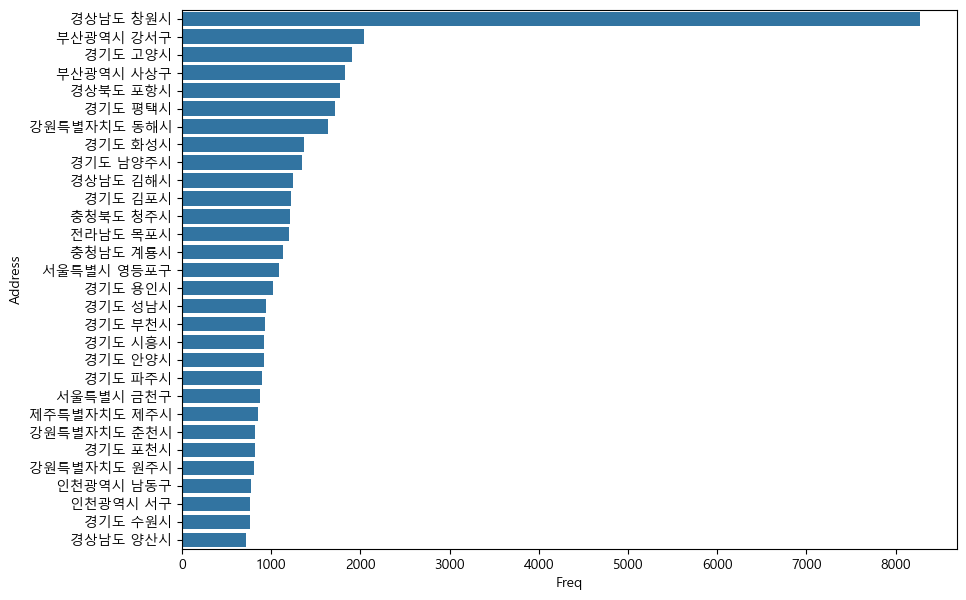

In [30]:
# 그래프 그리기
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(y = "Address",
                 x = "Freq",
                 data = add_count_df[:30])

plt.show()

In [84]:
발주기관 = df['발주기관'].unique()
발주기관df = pd.DataFrame(발주기관, columns = ['발주기관'])
발주기관df

,발주기관
0,제3283부대
1,육군훈련소
2,제2307부대
3,국군재정관리단
4,공군사관학교
...,...
240,제2238부대
241,국방기술품질원
242,육군 1군 102기갑여단
243,전략사령부


In [45]:
df['군 분류'].unique()

array(['육군', '기타', '공군', '해병', '국방부직할', '해군'], dtype=object)

In [96]:
df['발주기관'].astype(str).str.len().max()

20

In [95]:
군df = df[['군 분류', '발주기관']]
군df = 군df.drop_duplicates()
# 군df.to_csv('군csv.csv', index=False, encoding='cp949')

In [55]:
육군df = pd.DataFrame(df[df['군 분류']=='육군']['발주기관'].unique(), columns=['군 분류'])

In [57]:
군분류이름 = []
for i in df['군 분류'].unique():
    군분류이름.append(f'{i}df')
군분류이름

['육군df', '기타df', '공군df', '해병df', '국방부직할df', '해군df']

In [76]:
for i in df['군 분류'].unique():
    globals()[f'{i}df'] = pd.DataFrame(df[df['군 분류'] == i]['발주기관'].unique(), columns=['발주기관'])
    print(f"{i}df 데이터프레임:")
    print(globals()[f'{i}df'])

육군df 데이터프레임:
              발주기관
0          제3283부대
1            육군훈련소
2          제2307부대
3           제1보병사단
4           제5보병사단
..             ...
128        제2112부대
129        제7군수지원단
130        드론작전사령부
131        제2238부대
132  육군 1군 102기갑여단

[133 rows x 1 columns]
기타df 데이터프레임:
       발주기관
0   국군재정관리단
1   국군의무사령부
2    국군대전병원
3    국군수도병원
4   합동군사대학교
5  국군간호사관학교
6    국군체육부대
7     국군복지단
8   국립서울현충원
9  한미연합군사령부
공군df 데이터프레임:
                  발주기관
0               공군사관학교
1              공군교육사령부
2              제3훈련비행단
3         공군제15특수임무비행단
4           공군제19전투비행단
5            공군방공관제사령부
6              공군군수사령부
7           공군제17전투비행단
8   공군 작사예하 방포사예하 제2여단
9           공군제11전투비행단
10         공군제5공중기동비행단
11          공군미사일방어사령부
12          공군제18전투비행단
13           공군작사근무지원단
14           공군제1전투비행단
15         공군제38전투비행전대
16            제20전투비행단
17          공군 제8전투비행단
18                공군본부
19          공군제10전투비행단
20          공군제16전투비행단
21             공군항공안전단
22          공군제7항공통신전대
23  공군 작사예하 방포사예하 제3여단
24

In [86]:
군분류_df = pd.merge(발주기관df, df[['발주기관', '군 분류']], 
                     on=['발주기관'], how='left')
군분류_df

,발주기관,군 분류
0,제3283부대,육군
1,제3283부대,육군
2,제3283부대,육군
3,제3283부대,육군
4,제3283부대,육군
...,...,...
74725,해상공중전력운영계약팀,국방부직할
74726,해상공중전력운영계약팀,국방부직할
74727,해상공중전력운영계약팀,국방부직할
74728,해상공중전력운영계약팀,국방부직할
